<a href="https://colab.research.google.com/github/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation/blob/main/DRAFT%20Test%20Glob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crime Data Analysis of WMP

#Clone files from Github

In [ ]:
!pip install panel jupyter_bokeh
!pip install hvplot

In [ ]:
! git clone https://github.com/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation.git
#/content/L7---Data-Analysis-and-Visualisation

Cloning into 'L7---Data-Analysis-and-Visualisation'...
remote: Enumerating objects: 224, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 224 (delta 52), reused 20 (delta 20), pack-reused 153 (from 1)
Receiving objects: 100% (224/224), 45.35 MiB | 23.72 MiB/s, done.
Resolving deltas: 100% (140/140), done.
Updating files: 100% (56/56), done.


#1. Importing Libriaries

In [ ]:
import pandas as pd
import glob as glob
import panel as pn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pn.extension(comms='colab')
pn.extension('tabulator')
import hvplot.pandas

#2. Import Data

In [ ]:
RawData=glob.glob("/content/L7---Data-Analysis-and-Visualisation/Raw Data/*.csv")
RawData

['/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-11-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-05-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-03-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-08-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-08-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-02-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2023-12-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2023-12-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-04-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-04-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-05-staffordshire-s

In [ ]:
list_df=[]
for csvfile in RawData:
  df=pd.read_csv(csvfile)
  list_df.append(df)

In [ ]:
  list_df

[                                                Crime ID    Month  \
 0                                                    NaN  2024-11   
 1      c57b9a587cae18f6332faaecf52d5526f6eff1212b9d87...  2024-11   
 2      50def1202324cdac14916099fb3334d747a64006816c50...  2024-11   
 3                                                    NaN  2024-11   
 4      9a8770e587aecb0020c7a83554f46c37699f951b55978a...  2024-11   
 ...                                                  ...      ...   
 26566  e2a141e82a6df9055d131f02c0bdb3c082aa20adaca7ff...  2024-11   
 26567  f763e5ca98f413d37f47cd49be0be57880c8ae1601d232...  2024-11   
 26568  60abd2c01d69c8dfaad9d0a34cfe843783b63011913299...  2024-11   
 26569  971c376dfe16fd66c25d3e771b4ed488d49dc29284d25d...  2024-11   
 26570  7873c497fc5d41b3cfa674e43881821f76192d9769c1d1...  2024-11   
 
                 Reported by          Falls within  Longitude   Latitude  \
 0      West Midlands Police  West Midlands Police  -1.851067  52.593204   
 1    

In [ ]:
#Check how mange items, expect 24+24=48 as a result
len(list_df)

48

#Concatenate all CSV into one DataFrame

In [ ]:
CrimeData = pd.concat(list_df,axis=0, ignore_index=True) # axis=0 meaning row concatenation and 1 is for column
CrimeData

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,NaN,2024-11,West Midlands Police,West Midlands Police,-1.851067,52.593204,On or near Longdon Drive,E01009417,Birmingham 001A,Anti-social behaviour,NaN,NaN
1,c57b9a587cae18f6332faaecf52d5526f6eff1212b9d87...,2024-11,West Midlands Police,West Midlands Police,-1.845479,52.591165,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Other theft,Unable to prosecute suspect,NaN
2,50def1202324cdac14916099fb3334d747a64006816c50...,2024-11,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
3,NaN,2024-11,West Midlands Police,West Midlands Police,-1.839093,52.597818,On or near Byron Court,E01009418,Birmingham 001B,Anti-social behaviour,NaN,NaN
4,9a8770e587aecb0020c7a83554f46c37699f951b55978a...,2024-11,West Midlands Police,West Midlands Police,-1.845233,52.593943,On or near Harcourt Drive,E01009418,Birmingham 001B,Burglary,Unable to prosecute suspect,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
869242,da65818fcba1e6a3c1316d256e0b7ef4e5d432a47857db...,2024-06,West Midlands Police,West Midlands Police,-2.119472,52.572273,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Vehicle crime,Investigation complete; no suspect identified,NaN
869243,dc325458ceeee7b5a4f539f113b085657dce72834c401b...,2024-06,West Midlands Police,West Midlands Police,-2.118325,52.573820,On or near Pond Grove,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN
869244,a5005156fc60263c77d18de447519d2908201e8ea40265...,2024-06,West Midlands Police,West Midlands Police,-2.119472,52.572273,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN
869245,74de572ccb66d1d650ffc0f34cbd7e8445c8bed863fae5...,2024-06,West Midlands Police,West Midlands Police,-2.119472,52.572273,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN


#Structure and Shape

In [ ]:
CrimeData.shape # Dimentions of the DataFrame (number of rows and columns)

(869247, 12)

In [ ]:
CrimeData.index #
#CrimeData.index.to_list()

RangeIndex(start=0, stop=869247, step=1)

In [ ]:
print("colomns:\n", CrimeData.columns) # Column names of the DataFrame
print("colomns:\n", CrimeData.columns.to_list()) # In list

colomns:
 Index(['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude',
       'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type',
       'Last outcome category', 'Context'],
      dtype='object')
colomns:
 ['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude', 'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type', 'Last outcome category', 'Context']


In [ ]:
CrimeData.info()
# number of rows/records
# any null values in each colum, how complete the columns are populated in the data set
# what are the types of attributes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               789910 non-null  object 
 1   Month                  869247 non-null  object 
 2   Reported by            869247 non-null  object 
 3   Falls within           869247 non-null  object 
 4   Longitude              868316 non-null  float64
 5   Latitude               868316 non-null  float64
 6   Location               869247 non-null  object 
 7   LSOA code              868316 non-null  object 
 8   LSOA name              868316 non-null  object 
 9   Crime type             869247 non-null  object 
 10  Last outcome category  789910 non-null  object 
 11  Context                0 non-null       float64
dtypes: float64(3), object(9)
memory usage: 79.6+ MB


#Content

In [ ]:
CrimeData.head()
CrimeData.tail()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
869242,da65818fcba1e6a3c1316d256e0b7ef4e5d432a47857db...,2024-06,West Midlands Police,West Midlands Police,-2.119472,52.572273,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Vehicle crime,Investigation complete; no suspect identified,NaN
869243,dc325458ceeee7b5a4f539f113b085657dce72834c401b...,2024-06,West Midlands Police,West Midlands Police,-2.118325,52.573820,On or near Pond Grove,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN
869244,a5005156fc60263c77d18de447519d2908201e8ea40265...,2024-06,West Midlands Police,West Midlands Police,-2.119472,52.572273,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN
869245,74de572ccb66d1d650ffc0f34cbd7e8445c8bed863fae5...,2024-06,West Midlands Police,West Midlands Police,-2.119472,52.572273,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN
869246,97e80c3ae3600f1f0e4b3d9dcb03b0016487419348361b...,2024-06,West Midlands Police,West Midlands Police,-2.118019,52.569505,On or near Thompson Avenue,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN


#Detecting missing values

In [ ]:
CrimeData.isna()
CrimeData.isnull()
CrimeData.isna().sum()
CrimeData.isnull().sum()

,0
Crime ID,79337
Month,0
Reported by,0
Falls within,0
Longitude,931
Latitude,931
Location,0
LSOA code,931
LSOA name,931
Crime type,0


#Selecting part of the DataFrame or Drop parts not needed

In [ ]:
CleanData=CrimeData.loc[:, ['Month', 'Reported by','Location','LSOA code','LSOA name','Crime type','Last outcome category']] #select Columns needed
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2024-11,West Midlands Police,On or near Longdon Drive,E01009417,Birmingham 001A,Anti-social behaviour,NaN
1,2024-11,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Other theft,Unable to prosecute suspect
2,2024-11,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Unable to prosecute suspect
3,2024-11,West Midlands Police,On or near Byron Court,E01009418,Birmingham 001B,Anti-social behaviour,NaN
4,2024-11,West Midlands Police,On or near Harcourt Drive,E01009418,Birmingham 001B,Burglary,Unable to prosecute suspect
...,...,...,...,...,...,...,...
869242,2024-06,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Vehicle crime,Investigation complete; no suspect identified
869243,2024-06,West Midlands Police,On or near Pond Grove,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869244,2024-06,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869245,2024-06,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect


In [ ]:
#Double Check if both datasets brought in
CleanData['Reported by'].value_counts()

,count
Reported by,
West Midlands Police,668108
Staffordshire Police,201139


#!!!!!!!!Reference external data here on if these number of Crimes overal reconcil other national statistics;

#!!!!!!!!Aslo be aware one ID might be against >1 crime, this might or might not be DQ issue, double check this, didn't seem so in my data

# Handling Missing Data

In [ ]:
CleanData.fillna('Data not recorded', inplace=True) # Fill the blank values with 'data not recorded' for outcome column
CleanData.info() # check if fillna worked

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Month                  869247 non-null  object
 1   Reported by            869247 non-null  object
 2   Location               869247 non-null  object
 3   LSOA code              869247 non-null  object
 4   LSOA name              869247 non-null  object
 5   Crime type             869247 non-null  object
 6   Last outcome category  869247 non-null  object
dtypes: object(7)
memory usage: 46.4+ MB


In [ ]:
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2024-11,West Midlands Police,On or near Longdon Drive,E01009417,Birmingham 001A,Anti-social behaviour,Data not recorded
1,2024-11,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Other theft,Unable to prosecute suspect
2,2024-11,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Unable to prosecute suspect
3,2024-11,West Midlands Police,On or near Byron Court,E01009418,Birmingham 001B,Anti-social behaviour,Data not recorded
4,2024-11,West Midlands Police,On or near Harcourt Drive,E01009418,Birmingham 001B,Burglary,Unable to prosecute suspect
...,...,...,...,...,...,...,...
869242,2024-06,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Vehicle crime,Investigation complete; no suspect identified
869243,2024-06,West Midlands Police,On or near Pond Grove,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869244,2024-06,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect
869245,2024-06,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect


#Handling Data Quality Issue
Review Crimes and Outcomes, check any duplication/Similar inputs to tidy up

In [ ]:
CleanData['Crime type'].value_counts()
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Data not recorded,79337
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528


In [ ]:
# Handling typo or duplications
CleanData.replace({"Formal action is not in the public interest":"Further action is not in the public interest"}, inplace=True)
CleanData.replace({"Further investigation is not in the public interest":"Further action is not in the public interest"}, inplace=True)


In [ ]:
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Data not recorded,79337
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528


#1.   Bring in two workforce data
#2.   Import LSOA data in one sheet
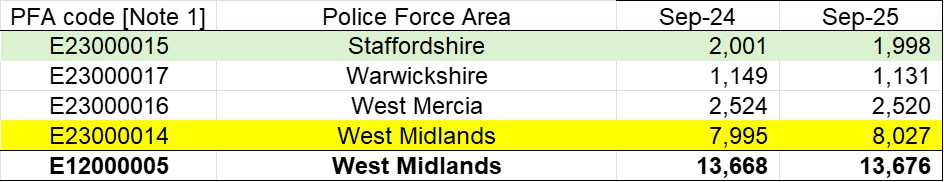


In [ ]:
FTE={
    'Reported by': ['West Midlands Police', 'Staffordshire Police'],
        'Police FTE': ['8027',	'1998']}
WorkForceFTE = pd.DataFrame(FTE)
WorkForceFTE

,Reported by,Police FTE
0,West Midlands Police,8027
1,Staffordshire Police,1998


#Merge supplimentary datasets
Append Police Work Force Data

Append LSOA Data


In [ ]:
LSOAdata=pd.read_excel("/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025_All_Ranks_Scores_Deciles_Population_Denominators.xlsx")
LSOAdata

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Score (rate),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Score","Education, Skills and Training Rank (where 1 is most deprived)","Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA
0,E01000001,City of London 001A,E09000001,City of London,8.742,26525,8,0.013,33730,10,0.014,33708,10,0.004,33755,10,2172
1,E01000002,City of London 001B,E09000001,City of London,4.722,31203,10,0.018,33669,10,0.010,33734,10,0.169,33672,10,2044
2,E01000003,City of London 001C,E09000001,City of London,9.250,25913,8,0.107,25167,8,0.064,26985,8,3.269,30273,9,2444
3,E01000005,City of London 001E,E09000001,City of London,19.884,14807,5,0.211,14836,5,0.104,17911,6,17.852,15886,5,2391
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,25.307,10917,4,0.343,7519,3,0.120,15286,5,25.442,11134,4,1930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,E01035758,Vale of White Horse 014H,E07000180,Vale of White Horse,7.945,27536,9,0.101,25934,8,0.074,24575,8,10.893,21842,7,1216
33751,E01035759,Vale of White Horse 015G,E07000180,Vale of White Horse,7.622,27902,9,0.097,26440,8,0.081,22891,7,7.528,25326,8,1592
33752,E01035760,Vale of White Horse 015H,E07000180,Vale of White Horse,7.946,27532,9,0.170,18127,6,0.067,26383,8,10.064,22625,7,1827
33753,E01035761,Vale of White Horse 015I,E07000180,Vale of White Horse,6.682,28981,9,0.136,21596,7,0.054,29547,9,8.482,24267,8,1955


#Keep relevant columns from LSOA data

In [ ]:
LSOAdataclean=LSOAdata.loc[:, ['LSOA code (2021)','Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)','Income Decile (where 1 is most deprived 10% of LSOAs)','Employment Decile (where 1 is most deprived 10% of LSOAs)','Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)','Population LSOA']] #select Columns needed
LSOAdataclean

,LSOA code (2021),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA
0,E01000001,8,10,10,10,2172
1,E01000002,10,10,10,10,2044
2,E01000003,8,8,8,9,2444
3,E01000005,5,5,6,5,2391
4,E01000006,4,3,5,4,1930
...,...,...,...,...,...,...
33750,E01035758,9,8,8,7,1216
33751,E01035759,9,8,7,8,1592
33752,E01035760,9,6,8,7,1827
33753,E01035761,9,7,9,8,1955


#Rename Column for easy join

In [ ]:
LSOAdataclean.rename(columns={'LSOA code (2021)':'LSOA code'}, inplace=True)
LSOAdataclean

,LSOA code,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA
0,E01000001,8,10,10,10,2172
1,E01000002,10,10,10,10,2044
2,E01000003,8,8,8,9,2444
3,E01000005,5,5,6,5,2391
4,E01000006,4,3,5,4,1930
...,...,...,...,...,...,...
33750,E01035758,9,8,8,7,1216
33751,E01035759,9,8,7,8,1592
33752,E01035760,9,6,8,7,1827
33753,E01035761,9,7,9,8,1955


In [ ]:
#Merge LSOA data
DataMerge1=pd.merge(CleanData,LSOAdataclean,on='LSOA code',how='left')
#Merge workforce data
DataMerge=pd.merge(DataMerge1,WorkForceFTE,on='Reported by',how='left')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA,Police FTE
0,2024-11,West Midlands Police,On or near Longdon Drive,E01009417,Birmingham 001A,Anti-social behaviour,Data not recorded,9.0,8.0,8.0,9.0,1554.0,8027
1,2024-11,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Other theft,Unable to prosecute suspect,9.0,8.0,8.0,9.0,1554.0,8027
2,2024-11,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Unable to prosecute suspect,9.0,8.0,8.0,9.0,1554.0,8027
3,2024-11,West Midlands Police,On or near Byron Court,E01009418,Birmingham 001B,Anti-social behaviour,Data not recorded,5.0,5.0,4.0,8.0,1615.0,8027
4,2024-11,West Midlands Police,On or near Harcourt Drive,E01009418,Birmingham 001B,Burglary,Unable to prosecute suspect,5.0,5.0,4.0,8.0,1615.0,8027
...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2024-06,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Vehicle crime,Investigation complete; no suspect identified,3.0,2.0,4.0,2.0,1372.0,8027
869243,2024-06,West Midlands Police,On or near Pond Grove,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,2.0,4.0,2.0,1372.0,8027
869244,2024-06,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,2.0,4.0,2.0,1372.0,8027
869245,2024-06,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,2.0,4.0,2.0,1372.0,8027


#Creat months group for first and second 12 months for later comparision

In [ ]:
#change data type for Column "Month"
DataMerge['Month'] = pd.to_datetime(DataMerge['Month'])
start_date = pd.to_datetime('2023-12')
end_date = pd.to_datetime('2024-11')

DataMerge['Month Group'] = DataMerge['Month'].apply(lambda x: 'first 12 months' if (x >= start_date and x <= end_date) else 'second 12 months')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA,Police FTE,Month Group
0,2024-11-01,West Midlands Police,On or near Longdon Drive,E01009417,Birmingham 001A,Anti-social behaviour,Data not recorded,9.0,8.0,8.0,9.0,1554.0,8027,first 12 months
1,2024-11-01,West Midlands Police,On or near Four Oaks Common Road,E01009417,Birmingham 001A,Other theft,Unable to prosecute suspect,9.0,8.0,8.0,9.0,1554.0,8027,first 12 months
2,2024-11-01,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Unable to prosecute suspect,9.0,8.0,8.0,9.0,1554.0,8027,first 12 months
3,2024-11-01,West Midlands Police,On or near Byron Court,E01009418,Birmingham 001B,Anti-social behaviour,Data not recorded,5.0,5.0,4.0,8.0,1615.0,8027,first 12 months
4,2024-11-01,West Midlands Police,On or near Harcourt Drive,E01009418,Birmingham 001B,Burglary,Unable to prosecute suspect,5.0,5.0,4.0,8.0,1615.0,8027,first 12 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2024-06-01,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Vehicle crime,Investigation complete; no suspect identified,3.0,2.0,4.0,2.0,1372.0,8027,first 12 months
869243,2024-06-01,West Midlands Police,On or near Pond Grove,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,2.0,4.0,2.0,1372.0,8027,first 12 months
869244,2024-06-01,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,2.0,4.0,2.0,1372.0,8027,first 12 months
869245,2024-06-01,West Midlands Police,On or near Silver Birch Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,3.0,2.0,4.0,2.0,1372.0,8027,first 12 months


In [ ]:
crime_counts = DataMerge.groupby(['Reported by','Month Group']).size().reset_index(name='CrimeCount')
crime_counts

,Reported by,Month Group,CrimeCount
0,Staffordshire Police,first 12 months,99527
1,Staffordshire Police,second 12 months,101612
2,West Midlands Police,first 12 months,344501
3,West Midlands Police,second 12 months,323607


In [ ]:
#Pivot previous table to use 'Month Group' as column headers
crime_counts_pivot = crime_counts.pivot_table(index='Reported by', columns='Month Group', values='CrimeCount').reset_index()
crime_counts_pivot.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot ['Variance %'] =(crime_counts_pivot['second 12 months']-crime_counts_pivot['first 12 months'])/crime_counts_pivot['first 12 months']*100
crime_counts_pivot ['Variance %'] = crime_counts_pivot['Variance %'].round(1)
crime_counts_pivot

,Reported by,first 12 months,second 12 months,Variance %
0,Staffordshire Police,99527.0,101612.0,2.1
1,West Midlands Police,344501.0,323607.0,-6.1


In [ ]:
# Variance number of crimes by types
crime_counts_type = DataMerge.groupby(['Crime type','Month Group']).size().reset_index(name='CrimeCount')
crime_counts_type
#Pivot the table use 'Month Group' as column headers
crime_counts_pivot2 = crime_counts_type.pivot_table(index='Crime type', columns='Month Group',values='CrimeCount').reset_index()
crime_counts_pivot2.columns.name = None # Remove the 'Month Group' column name

#Calculate variance of the first 12 months and second 12 months
crime_counts_pivot2 ['Variance %'] =(crime_counts_pivot2['second 12 months']-crime_counts_pivot2['first 12 months'])/crime_counts_pivot2['first 12 months']*100
crime_counts_pivot2['Variance %'] = crime_counts_pivot2['Variance %'].round(1)
crime_counts_pivot2.sort_values(by=["Variance %"],ascending=False)


,Crime type,first 12 months,second 12 months,Variance %
4,Drugs,9654.0,12390.0,28.3
10,Shoplifting,37609.0,39254.0,4.4
7,Possession of weapons,7441.0,7749.0,4.1
5,Other crime,8769.0,8747.0,-0.3
13,Violence and sexual offences,175857.0,172455.0,-1.9
0,Anti-social behaviour,40198.0,39139.0,-2.6
3,Criminal damage and arson,33451.0,31793.0,-5.0
8,Public order,28249.0,25914.0,-8.3
1,Bicycle theft,2772.0,2498.0,-9.9
11,Theft from the person,3244.0,2909.0,-10.3


#Analysis and Visualisation

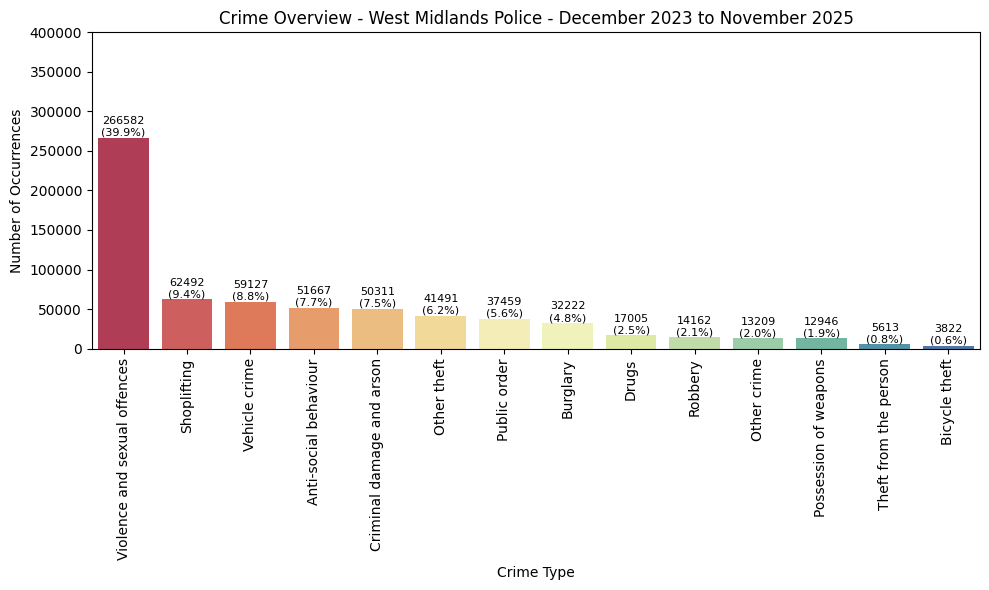

In [ ]:
#Bar Chart with percentages of total % For Crime Types
Police=['West Midlands Police']
chart1=CleanData[CleanData['Reported by'].isin(Police)]
crime_type_counts = chart1['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='Spectral', legend=False)
plt.title('Crime Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 400000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

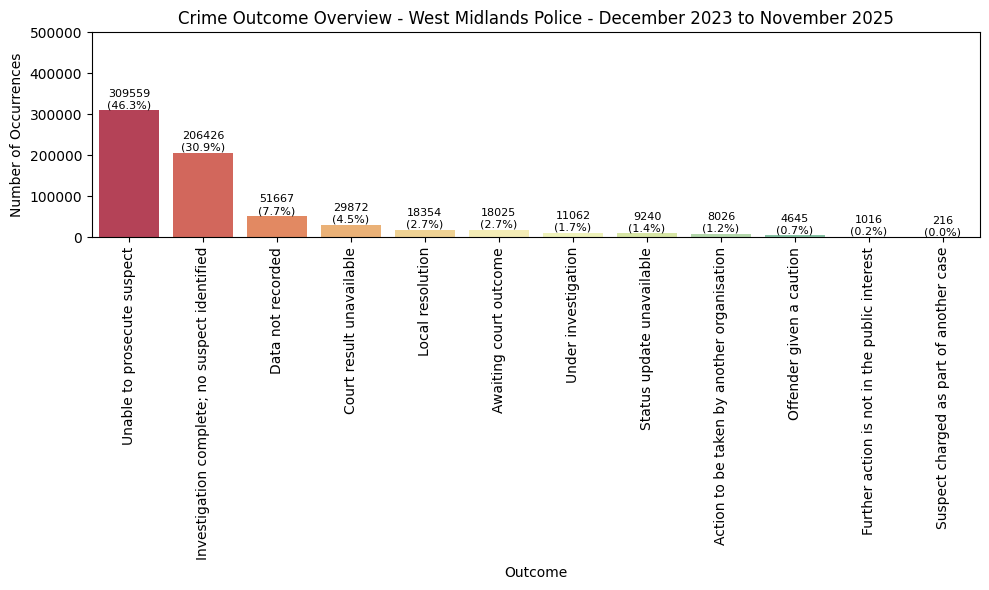

In [ ]:
#Bar Chart with percentages of total %
#Police=['West Midlands Police']
#chart1=CleanData[CleanData['Reported by'].isin(Police)]
outcome_counts = chart1['Last outcome category'].value_counts()
total_crimes = outcome_counts.sum()
outcome_percentages = (outcome_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette='Spectral', legend=False) #viridis
plt.title('Crime Outcome Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 500000)
plt.xlabel('Outcome')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(outcome_counts.values):
    percentage = outcome_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

#Creat Radio Botton for Police Force names

In [ ]:
crime_over_time = DataMerge[['Reported by','Crime type','Month']].value_counts().reset_index(name='Count')
display(crime_over_time)

# Extract unique police forces BEFORE making crime_over_time interactive
#unique_police_forces = crime_over_time['Reported by'].unique().tolist()

crime_over_time = crime_over_time.interactive()

,Reported by,Crime type,Month,Count
0,West Midlands Police,Violence and sexual offences,2024-05-01,12342
1,West Midlands Police,Violence and sexual offences,2025-07-01,12230
2,West Midlands Police,Violence and sexual offences,2024-07-01,12226
3,West Midlands Police,Violence and sexual offences,2025-06-01,11895
4,West Midlands Police,Violence and sexual offences,2024-06-01,11862
...,...,...,...,...
667,Staffordshire Police,Theft from the person,2025-06-01,18
668,Staffordshire Police,Theft from the person,2025-05-01,17
669,Staffordshire Police,Theft from the person,2024-03-01,15
670,Staffordshire Police,Theft from the person,2025-09-01,13


In [ ]:
crime_over_time_pivot_full = crime_over_time.pivot_table(index=['Month', 'Crime type'], columns='Reported by', values='Count').reset_index()
crime_over_time_pivot_full.columns.name = None # Remove the column name for clarity
display(crime_over_time_pivot_full)

In [ ]:
yaxis_police = pn.widgets.RadioButtonGroup(
    name='Police Force',
    options=['West Midlands Police','Staffordshire Police',],
    button_type='success'
    )
yaxis_police

RadioButtonGroup(button_type='success', name='Police Force', options=['West Midlands Police', ...], value='West Midlands Police')

In [ ]:
crime_pipeline =(
    crime_over_time_pivot_full
    .groupby(['Crime type','Month'])[yaxis_police].sum()
    .reset_index()
    .sort_values(by='Month')
    .reset_index(drop=True)
                 )

crime_pipeline

#Seasonal trend over 24 months
##Interactive Chart all buttons can be used

In [ ]:
crime_plot=crime_pipeline.hvplot(x='Month', by='Crime type', y=yaxis_police, line_width=2, width=1000, height=500, title ="Crime over time")
crime_plot

#Corelation between LSOA metrics and Crime Rate Per 12 Month/Year, not 24 Months

In [ ]:
crime_counts_lsoa = DataMerge.groupby(['LSOA name','Reported by','Population LSOA','Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)']).size().reset_index(name='CrimeCount')
crime_counts_lsoa['Weighted Crime/1000 population']=(crime_counts_lsoa['CrimeCount']/crime_counts_lsoa['Population LSOA'].astype(float))*1000/2 # 12 months not total 24 months
crime_counts_lsoa['Weighted Crime/1000 population']=crime_counts_lsoa['Weighted Crime/1000 population'].round(2)
crime_counts_lsoa.sort_values(by=["Weighted Crime/1000 population"],ascending=False)
crime_counts_lsoa
#Police=['West Midlands Police']
#a=crime_counts_lsoa[crime_counts_lsoa['Reported by'].isin(Police)]
#a
#a.sort_values(by=["Weighted Crime/1000 population"],ascending=False)

,LSOA name,Reported by,Population LSOA,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),CrimeCount,Weighted Crime/1000 population
0,Ashfield 001C,Staffordshire Police,1834.0,6.0,1,0.27
1,Ashfield 012B,Staffordshire Police,1399.0,5.0,1,0.36
2,Barking and Dagenham 007D,Staffordshire Police,2109.0,4.0,1,0.24
3,Barnsley 005E,Staffordshire Police,2053.0,8.0,1,0.24
4,Barnsley 007C,Staffordshire Police,1671.0,1.0,1,0.30
...,...,...,...,...,...,...
2941,Wyre Forest 001E,Staffordshire Police,1810.0,2.0,12,3.31
2942,Wyre Forest 001F,Staffordshire Police,2534.0,5.0,1,0.20
2943,Wyre Forest 005C,Staffordshire Police,1855.0,2.0,1,0.27
2944,Wyre Forest 011E,Staffordshire Police,1440.0,3.0,1,0.35


#Creat NEW Column 'Weighted Crime/1000 WTF police'
#Creat NEW Column 'Weighted Crime/1000 population'


In [ ]:
b=crime_counts_lsoa.pivot_table(index='Reported by',values="Population LSOA",aggfunc='sum')
c=crime_counts_lsoa.pivot_table(index='Reported by',values="CrimeCount",aggfunc='sum')
e=DataMerge.pivot_table(index='Reported by',values="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)",aggfunc='mean')

WorkForceFTE,b,c,e
#merge and calculate weighted data by police
d=pd.merge(c,b,on='Reported by',how='left')
f=pd.merge(d,e,on='Reported by',how='left')
weighted_data=pd.merge(f,WorkForceFTE,on='Reported by',how='left')
weighted_data['Crime/1000 population/12 Months']=(weighted_data['CrimeCount']/weighted_data['Population LSOA'].astype(float))*1000/2
weighted_data['Crime/Police FTE/12 Months']=(weighted_data['CrimeCount']/weighted_data['Police FTE'].astype(float))*1000/2

weighted_data



,Reported by,CrimeCount,Population LSOA,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Police FTE,Crime/1000 population/12 Months,Crime/Police FTE/12 Months
0,Staffordshire Police,200191,2082499.0,4.171666,1998,48.065089,50097.847848
1,West Midlands Police,668108,3113162.0,2.977135,8027,107.303764,41616.295004


#Correlations
##test of Staffordshire police indeed perform better or West Midlands Deprivation drove it more
#limitation
the LOSA data missing in the dataset, in this project we only assume the outcome based on data available
check if there is a positive correlation bettween deprevation and Crime Rate

In [ ]:
correlation_deprivation = crime_counts_lsoa.groupby(['Reported by', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)'])['Weighted Crime/1000 population'].mean().reset_index()
#correlation_employment = crime_counts_lsoa1.groupby(['Reported by', 'Employment Decile (where 1 is most deprived 10% of LSOAs)'])['Weighted Crime/1000 population'].mean().reset_index()
#correlation_income = crime_counts_lsoa.groupby(['Reported by', 'Income Decile (where 1 is most deprived 10% of LSOAs)'])['Weighted Crime/1000 population'].mean().reset_index()


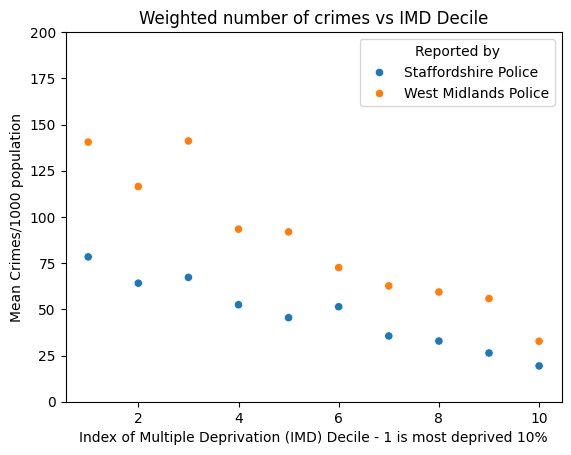

In [ ]:
sns.scatterplot(data=correlation_deprivation, x="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)", y="Weighted Crime/1000 population", hue="Reported by")
plt.title('Weighted number of crimes vs IMD Decile')
plt.xlabel('Index of Multiple Deprivation (IMD) Decile - 1 is most deprived 10%')
plt.ylabel('Mean Crimes/1000 population')
plt.ylim(0, 200)
plt.show()

In [ ]:
crime_counts_lsoa1 = DataMerge.groupby(['Reported by','LSOA name','Population LSOA','Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)']).size().reset_index(name='CrimeCount')
crime_counts_lsoa1['Weighted Crime/1000 population']=(crime_counts_lsoa['CrimeCount']/crime_counts_lsoa['Population LSOA'].astype(float))*1000/2 # 12 months not total 24 months
crime_counts_lsoa1['Weighted Crime/1000 population']=crime_counts_lsoa['Weighted Crime/1000 population'].round(2)
crime_counts_lsoa1.sort_values(by=["Weighted Crime/1000 population"],ascending=False)
crime_counts_lsoa1

,Reported by,LSOA name,Population LSOA,"Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",CrimeCount,Weighted Crime/1000 population
0,Staffordshire Police,Ashfield 001C,1834.0,6.0,1,0.27
1,Staffordshire Police,Ashfield 012B,1399.0,3.0,1,0.36
2,Staffordshire Police,Barking and Dagenham 007D,2109.0,4.0,1,0.24
3,Staffordshire Police,Barnsley 005E,2053.0,8.0,1,0.24
4,Staffordshire Police,Barnsley 007C,1671.0,1.0,1,0.30
...,...,...,...,...,...,...
2941,West Midlands Police,Wolverhampton 035E,1643.0,1.0,468,142.42
2942,West Midlands Police,Wolverhampton 035G,1831.0,2.0,332,90.66
2943,West Midlands Police,Wolverhampton 035H,2383.0,1.0,1272,266.89
2944,West Midlands Police,Wolverhampton 035I,2172.0,3.0,345,79.42


In [ ]:
correlation_education = crime_counts_lsoa1.groupby(['Reported by', 'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)'])['Weighted Crime/1000 population'].mean().reset_index()

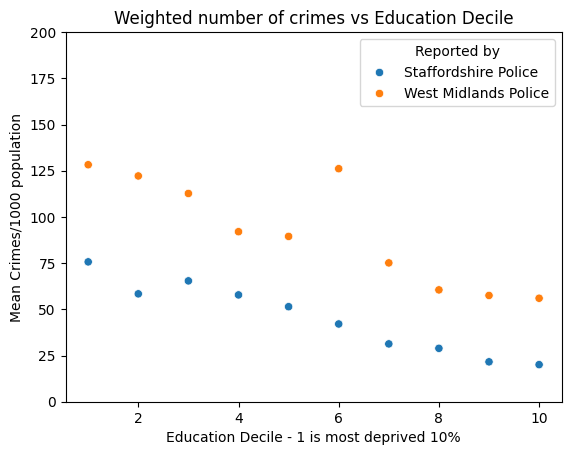

In [ ]:
sns.scatterplot(data=correlation_education, x="Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)", y="Weighted Crime/1000 population", hue="Reported by")
plt.title('Weighted number of crimes vs Education Decile')
plt.xlabel('Education Decile - 1 is most deprived 10%')
plt.ylabel('Mean Crimes/1000 population')
plt.ylim(0, 200)
plt.show()

#how much each metric contribute to IMD
#Start Early
https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025/english-indices-of-deprivation-2025-frequently-asked-questions#:~:text=There%20is%20not%20a%20definitive,described%20as%20'deprived').&text=Because%20there%20are%2033%2C755%20LSOAs,100/5=20).

#How likely to get away with punishment/Cost of Crime

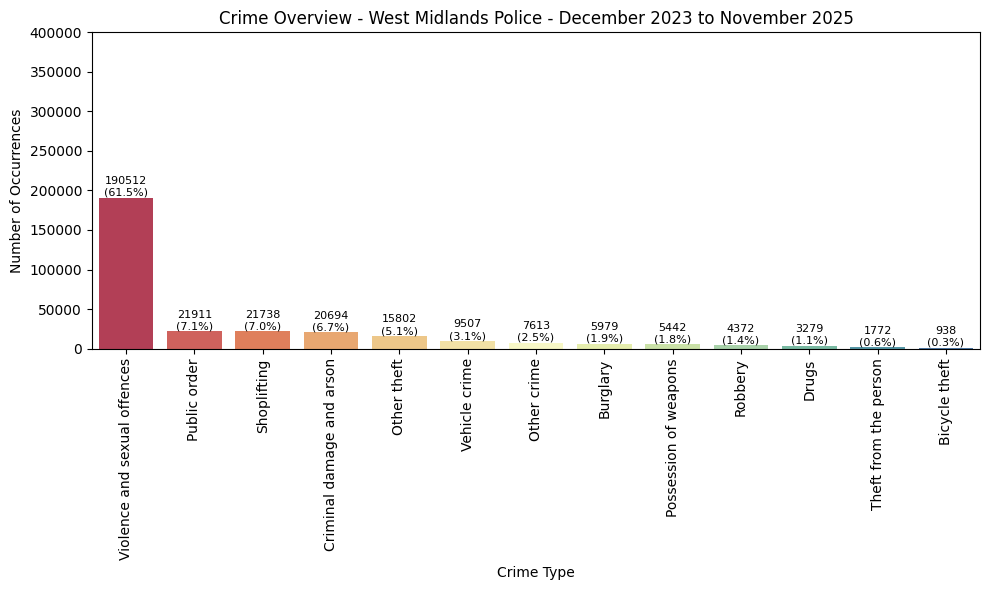

In [ ]:
#Bar Chart with percentages of total % For Crime Types
Outcome=['Unable to prosecute suspect']
Police=['West Midlands Police']
chart1=CleanData[CleanData['Reported by'].isin(Police) & CleanData['Last outcome category'].isin(Outcome)]
crime_type_counts = chart1['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='Spectral', legend=False)
plt.title('Crime Overview - West Midlands Police - December 2023 to November 2025')
plt.ylim(0, 400000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

#AntiSocial does not have outcome recorded

In [ ]:
# First, filter DataMerge by the specified Outcome
filtered_data1 = DataMerge[DataMerge['Reported by'].isin(Police)]
filtered_data2 = DataMerge[DataMerge['Last outcome category'].isin(Outcome) & DataMerge['Reported by'].isin(Police)]
# Then, group the filtered data by 'Crime type' to get the counts
crime_counts_type1 = filtered_data1.groupby(['Crime type']).size().reset_index(name='CrimeCount')
crime_counts_type2 = filtered_data2.groupby(['Crime type']).size().reset_index(name='CrimeCount-Unproscuted')
unproscuted_rate=pd.merge(crime_counts_type1,crime_counts_type2,on='Crime type',how='left')
unproscuted_rate['unproscuted_rate%']=(unproscuted_rate['CrimeCount-Unproscuted']/unproscuted_rate['CrimeCount'].astype(float))*100
unproscuted_rate['unproscuted_rate%']=unproscuted_rate['unproscuted_rate%'].round(1)
unproscuted_rate.sort_values(by=["unproscuted_rate%"],ascending=False)

,Crime type,CrimeCount,CrimeCount-Unproscuted,unproscuted_rate%
13,Violence and sexual offences,266582,190512.0,71.5
8,Public order,37459,21911.0,58.5
5,Other crime,13209,7613.0,57.6
7,Possession of weapons,12946,5442.0,42.0
3,Criminal damage and arson,50311,20694.0,41.1
6,Other theft,41491,15802.0,38.1
10,Shoplifting,62492,21738.0,34.8
11,Theft from the person,5613,1772.0,31.6
9,Robbery,14162,4372.0,30.9
1,Bicycle theft,3822,938.0,24.5


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=unproscuted_rate, x='Crime type', y='unproscuted_rate%', order=unproscuted_rate.sort_values(by='unproscuted_rate%', ascending=False)['Crime type'], palette='Spectral', legend=False)
plt.title('West Midlands Police-Unproscuted rate by Crime %')
plt.ylim(0, 100)
plt.xlabel('Crime Type')
plt.ylabel('Unprosecuted Rate %')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()